In [53]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
import os
import langgraph.graph as lg
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from google.cloud import bigquery
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage

In [54]:
# ✅ Load environment variables (optional)
load_dotenv()

"""
# ✅ Set up Google BigQuery
key_path = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if key_path and os.path.exists(key_path):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = key_path
else:
    raise ValueError("❌ Google Cloud credentials not found!")

"""

client = bigquery.Client()
project_id = client.project  

# ✅ Connect SQLDatabase to BigQuery
db = SQLDatabase.from_uri(f"bigquery://{project_id}")

# ✅ Initialize LLM
llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_fast = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)



/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/google/cloud/bigquery/client.py:595: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(
/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/sqlalchemy_bigquery/_types.py:101: SAWarning: Did not recognize type 'GEOGRAPHY' of column 'distribution_center_geom'
  sqlalchemy.util.warn(
/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/sqlalchemy_bigquery/_types.py:101: SAWarning: Did not recognize type 'GEOGRAPHY' of column 'user_geom'
  sqlalchemy.util.warn(


## STATE DEFINITION

In [60]:
from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

## NL2SQL FUNCTIONS

In [56]:
def write_query(question: str) -> str:
    prompt = f"""
    You are an AI that generates SQL queries for a BigQuery database.

    **Database dialect:** {db.dialect}
    **Schema:** {db.get_table_info()}
    
    **User question:** "{question}"
    
    **Rules:**
    - You should write a query that answers the user question.
    - **Return only the SQL query.** No explanations.
    - The SQL query must be valid BigQuery SQL.
    - **Do not assume unknown columns.**
    
    Example Format:
    SELECT column FROM table WHERE condition;
    """
    raw_result = llm.invoke(prompt)

    sql_query = raw_result.content.strip().replace("```sql", "").replace("```", "").strip()
    return sql_query

def execute_query(sql_query: str) -> str:
    try:
        query_job = client.query(sql_query)
        results_df = query_job.result().to_dataframe()
        results_markdown = results_df.to_markdown()
        return results_markdown
    except Exception as e:
        return f"❌ Error: {str(e)}"

def summarize_result(sql_query: str, results: str) -> str:
    if "❌ Error" in results:
        return "I couldn't process the query due to an error."

    prompt = f"""
    You are a data analyst. Based on the following SQL query and its output, write a straightforward natural language answer that directly communicates the query result.

    **SQL Query:** 
    ```sql
    {sql_query}
    ```

    **Results:**
    {results}

    **Rules:**
    - Write in a conversational style.
    - Do not give an opinion or interpretation.

    Example:
    China was the country with the highest number of orders, with a total of 42,355 orders.
    """
    response = llm_fast.invoke(prompt)
    return response.content.strip()


In [37]:
from langchain_core.documents import Document

# ✅ Your RAG corpus
docs = [
    'The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.',
    'The top country for sales in January 2024 was the United States, with a total of 2 sales.',
    'In January 2024, the total sales for the product "Collections Etc - Tanya Circles V-Neck Dress" was $27.94.',
    'Customers who purchased the "Tanya Circles V-Neck Dress" also bought items such as leggings, jackets, and Bermuda shorts.',
    'The average discount applied to women’s dresses in January 2024 was 15%.',
    'January 2024 saw a promotional campaign focused on winter apparel, including dresses and sweaters.',
    'Social media engagement for the "Tanya Circles V-Neck Dress" peaked during the second week of January.',
    'Compared to January 2023, sales for the "Tanya Circles V-Neck Dress" increased by 20%.',
    'The product received an average customer rating of 4.8 stars out of 5 based on 9 reviews.',
    'Inventory levels for the "Tanya Circles V-Neck Dress" were higher than average, with sufficient stock in most regions.'
]


# ✅ Step 1: Wrap each string in a Document object
documents = [Document(page_content=text) for text in docs]

# ✅ Step 2: Split into chunks
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250,
    chunk_overlap=0
)
doc_splits = text_splitter.split_documents(documents)

# ✅ Step 3: Generate vector store
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=OpenAIEmbeddings(),
    persist_directory= None
    # can be None if in-memory
)

# ✅ Step 4: Create retriever
retriever = vectorstore.as_retriever()

print("✅ Vectorstore created from manually defined summaries.")


✅ Vectorstore created from manually defined summaries.


RETRIEVER PROMPT REWRITER

In [38]:
from langchain.prompts import ChatPromptTemplate
from langchain.chat_models import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# Model
llm = ChatOpenAI(model="gpt-4o", temperature=0.3)

# Prompt
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", 
     "You are a retrieval-optimized question rewriter.\n"
     "Given a user question, rewrite it so that it helps retrieve supporting context — including potential causal factors, drivers, or comparative insights that might explain the answer.\n"
     "Be detailed, use broader semantic cues, and don't simplify the question."),
    ("human", 
     "Original question: {question}\n\nRewritten retrieval query:")
])

# Chain
quesiion_rewriter = rewrite_prompt | llm | StrOutputParser()

#question = "What was the top selling product in January 2024?"
#uestion_rewriter.invoke({"question": question})

In [57]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# ---------------------- SETUP ----------------------

# 💡 1. Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# 💡 2. LLM with structured output
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 💡 3. Prompt for retrieval grading
grading = """You are a grader assessing whether a retrieved document could meaningfully support a *causal* explanation of the user's question.

The document does not need to contain the answer itself. Instead, it should contribute *indirectly* by providing:
- Background context
- Supporting data
- Possible contributing factors
- Insights into trends, behavior, or marketing

Only mark 'no' if the document is completely irrelevant to the product, timeframe, or topic.

Respond with a binary score:
- 'yes' if the document adds context, data, or causal clues to the question
- 'no' if it offers nothing helpful
"""

grade_prompt = ChatPromptTemplate.from_messages([
    ("system", grading),
    ("human", "Retrieved document: \n\n {document} \n\n User question: {question}, Initial answer: {initial_answer}")
])

# 💡 4. Create the chain
retrieval_grader = grade_prompt | structured_llm_grader

# ---------------------- DEBUGGING ----------------------

# This section is for inspecting the corpus, running the retriever, and manually testing the grader
# You can delete or comment this out in production

question = "What was the top selling product in January 2024?"
initial_answer = 'The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.'

docs = [
    'The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.',
    'The top country for sales in January 2024 was the United States, with a total of 2 sales.',
    'In January 2024, the total sales for the product "Collections Etc - Tanya Circles V-Neck Dress" was $27.94.',
    'Customers who purchased the "Tanya Circles V-Neck Dress" also bought items such as leggings, jackets, and Bermuda shorts.',
    'The average discount applied to women’s dresses in January 2024 was 15%.',
    'January 2024 saw a promotional campaign focused on winter apparel, including dresses and sweaters.',
    'Social media engagement for the "Tanya Circles V-Neck Dress" peaked during the second week of January.',
    'Compared to January 2023, sales for the "Tanya Circles V-Neck Dress" increased by 20%.',
    'The product received an average customer rating of 4.8 stars out of 5 based on 9 reviews.',
    'Inventory levels for the "Tanya Circles V-Neck Dress" were higher than average, with sufficient stock in most regions.'
]

# Run grader on each document for debugging
print("\n------- DEBUGGING: Relevance Checks -------\n")
for i, doc in enumerate(docs, 1):
    result = retrieval_grader.invoke({
        "question": question,
        "initial_answer": initial_answer,
        "document": doc
    })
    print(f"📄 Document {i}: {doc}")
    print(f"✅ Relevant? {result.binary_score}\n")



------- DEBUGGING: Relevance Checks -------

📄 Document 1: The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.
✅ Relevant? yes

📄 Document 2: The top country for sales in January 2024 was the United States, with a total of 2 sales.
✅ Relevant? yes

📄 Document 3: In January 2024, the total sales for the product "Collections Etc - Tanya Circles V-Neck Dress" was $27.94.
✅ Relevant? no

📄 Document 4: Customers who purchased the "Tanya Circles V-Neck Dress" also bought items such as leggings, jackets, and Bermuda shorts.
✅ Relevant? no

📄 Document 5: The average discount applied to women’s dresses in January 2024 was 15%.
✅ Relevant? no

📄 Document 6: January 2024 saw a promotional campaign focused on winter apparel, including dresses and sweaters.
✅ Relevant? yes

📄 Document 7: Social media engagement for the "Tanya Circles V-Neck Dress" peaked during the second week of January.
✅ Relevant? yes

📄 Document 8

In [ ]:
### Generate

from langchain import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = hub.pull("rlm/rag-prompt")
print(prompt)


# LLM
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

#Custom Causal Prompt

# Prompt

causal_prompt = ChatPromptTemplate.from_messages([
        """You are a reasoning assistant focused on generating causal insights from retrieved data.

Your goal is to explain the underlying factors, causes, or drivers related to the user's question using only the information provided in the context.

- Base your reasoning strictly on the facts present in the context.
- Do not speculate or introduce causes that are not explicitly supported.
- If the context lacks enough detail to determine a clear cause, respond that additional data is needed.

Question: {question}  
Context: {context}  
Causal Insight:"""])


# Chain
rag_chain = causal_prompt | llm | StrOutputParser()


question = "Why was the top selling product in January 2024?"
# Run
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


input_variables=['context', 'question'] input_types={} partial_variables={} metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})]
The top-selling product in January 2024, the "Collections Etc - Tanya Circles V-Neck Dress," can be attributed to several underlying factors:

1. **Promotional Campaign**: There was a promotional campaign focused on winter apparel, which included dresses. This likely increased visibility and interest in th

In [9]:
### Hallucination Grader

# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)


# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
#hallucination_grader.invoke({"documents": docs, "generation": generation})

In [10]:
### Answer Grader


# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
#answer_grader.invoke({"question": question, "generation": generation})

In [11]:
### Question Re-writer

# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

#question = "?"

question_rewriter = re_write_prompt | llm | StrOutputParser()
#question_rewriter.invoke({"question": question})

## MY ADDED NODES

In [58]:
def extra_question(state):
    
    
    #CAMBIAR ESTO
    """
    Generate internal SQL subquestions based on the initial answer.
    """
    prompt = f"""
    Based on the SQL summary below, generate 2 follow-up questions that could be answered using **only the internal e-commerce SQL database**.

    Your goal is to help the analyst understand the cause of the results or add more information. 

    Only ask questions that could be translated into valid SQL queries — for example, questions about:
    - Product categories
    - Number of orders
    - Average order value
    - Number of unique users
    - Regional patterns in the data

    ❌ Do not ask about external factors like culture, politics, or population size.

    Summary:
    {state['generation']}
    """

    out = llm_fast.invoke(prompt).content.strip()
    subquestions = [line.strip("-• ") for line in out.splitlines() if line.strip()]

    print("\n🔍 Refined Subquestions (SQL-answerable only):")
    for i, subq in enumerate(subquestions, 1):
        print(f"{i}. {subq}")

    return {**state, "subquestions": subquestions}


def subquestion_analysis(state):
    """
    This node executes each SQL-based subquestion and appends its result to the corpus.
    """
    summaries = []
    
    #CAMBIAR ESTO
    for i, subq in enumerate(state["subquestions"], 1):
        print(f"\n🔄 Running subquestion {i}: {subq}")
        sql = write_query(subq)
        result = execute_query(sql)
        summary = summarize_result(sql, result)
        print(f"📝 Summary {i}: {summary}")
        summaries.append(summary)
    return {**state, "documents": summaries}


def internet(state):
    """
    This node triggers a web search to enrich the knowledge corpus.
    """
    question = state["question"]
    # Logic to perform external search goes here
    return {"question": question}


def analyze_initial_sql_node(state):
    summaries = []
    """
    This is the starting node that performs the initial SQL query and generates a summary.
    """
    query = write_query(state["question"])
    results = execute_query(query)
    summary = summarize_result(query, results)
    summaries.append(state["initial_answer"])

    print("\n🧾 Initial Summary:")
    print(summary)

    return {**state, "initial_answer": generation, "documents": summaries}





## SELF RAG NODES

In [14]:
### Nodes


def retrieve(state):
    

    # Retrieve documents based on optimized query
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {**state, "documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {**state, "documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]
    initial_answer = state["documents"][0].page_content

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content, "initial_answer": initial_answer}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


### Edges


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"


def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [50]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(GraphState)

# -- Nodes --
workflow.add_node("initial_question", analyze_initial_sql_node)
workflow.add_node("retrieve", retrieve)
workflow.add_node("generate", generate)
workflow.add_node("extra_question", extra_question)
workflow.add_node("subquestion_analysis", subquestion_analysis)
workflow.add_node("internet", internet)

# -- Edges --
workflow.add_edge(START, "initial_question")
workflow.add_edge("initial_question", "extra_question")
#workflow.add_edge("extra_question", "subquestion_analysis")
workflow.add_edge("subquestion_analysis", "retrieve")
workflow.add_edge("retrieve", "generate")

# Conditional from generate
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "useful": END,
        "not supported": "generate",
        "not useful": "extra_question",
    }
)

# Conditional from extra_question → internal or external
workflow.add_conditional_edges(
    "extra_question",
    lambda state: state["source_type"],  # This should return 'internal' or 'external'
    {
        "internal": "subquestion_analysis",
        "external": "internet",
    }
)

# Both paths back to retrieve
workflow.add_edge("subquestion_analysis", "retrieve")
workflow.add_edge("internet", "retrieve")

# Compile
app = workflow.compile()


In [39]:
from pprint import pprint



def run(input):# Run
    inputs = {"question": input}
    for output in app.stream(inputs):
        for key, value in output.items():
            # Node
            pprint(f"Node '{key}':")
            # Optional: print full state at each node
            #pprint(value["keys"], indent=2, width=80, depth=None)
        pprint("\n---\n")
        

# Final generation
    pprint(value["generation"])

In [44]:


run("What was the top selling product in January 2024?")

---REWRITE QUESTION FOR RETRIEVAL---
---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---
'---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---'
"Node 'generate':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION DOES NOT ADDRESS QUESTION---
"Node 'generate':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---REWRITE QUESTION FOR RETRIEVAL---
---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION DOES NOT ADDRESS QUESTION---
"Node 'generate':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---REWRITE QUESTION FOR RETRIEVAL---
---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN D

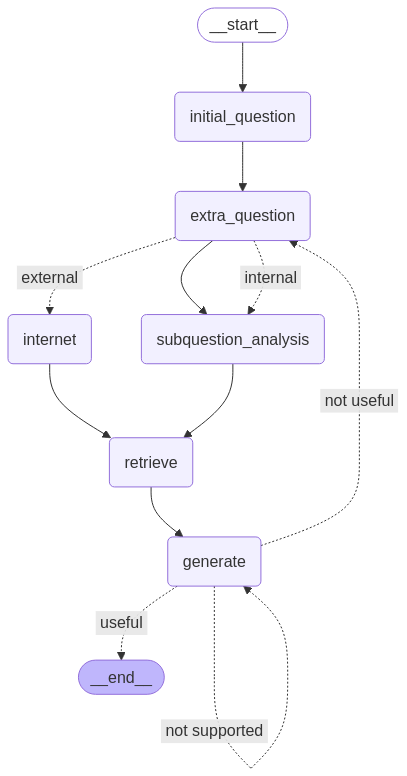

In [59]:
from IPython.display import Image, display


display(Image(app.get_graph().draw_mermaid_png()))
